In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ee
ee.Authenticate()
ee.Initialize()

In [24]:
test_start = '2024-01-01'
test_end = '2024-12-31'

start_month = ee.Date(test_start).update(day=1)
end_month = ee.Date(test_end)

n_months = end_month.difference(start_month, 'month')

months = ee.List.sequence(0, n_months.subtract(1))

collection = (
    ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
    .select(['tropospheric_NO2_column_number_density', 'cloud_fraction'])
)

def keep_good_quality(img):
    return img.updateMask(img.select('qa_value').gt(0.75))

point = ee.Geometry.Point([77.1, 28.95]) #coordinates of ashoka university
region = point.buffer(100000).bounds() #square bound 200k x 200k that contains a 100km radius buffer

In [25]:
current_size = collection.size().getInfo()
print(current_size)

if current_size > 0:
	first_image = collection.first()
	print(first_image.bandNames().getInfo())
	print(first_image.propertyNames().getInfo())
else:
	print("No images in collection after filtering; cannot read bandNames/propertyNames.")

39739
['tropospheric_NO2_column_number_density', 'cloud_fraction']
['LON_MIN', 'STATUS_NISE__', 'system:id', 'PLATFORM', 'STATUS_MET_2D', 'LAT_MAX', 'ORBIT', 'system:footprint', 'system:version', 'STATUS_CTMFCT', 'TIME_REFERENCE_DAYS_SINCE_1950', 'LAT_MIN', 'BUILD_DATE', 'INSTITUTION', 'system:time_end', 'SENSOR', 'L3_PROCESSING_VERSION', 'PRODUCT_ID', 'PRODUCT_QUALITY', 'PROCESSOR_VERSION', 'LON_MAX', 'PROCESSING_STATUS', 'system:time_start', 'HARP_VERSION', 'TRACKING_ID', 'SPATIAL_RESOLUTION', 'ALGORITHM_VERSION', 'L3_PROCESSING_TIME', 'system:asset_size', 'TIME_REFERENCE_JULIAN_DAY', 'system:index', 'system:bands', 'system:band_names']


In [26]:
def make_monthly_missing(m):
    start = start_month.advance(m, 'month')
    end = start.advance(1, 'month')
    
    monthly = collection.filterDate(start, end)
    
    band = 'tropospheric_NO2_column_number_density'
    
    # --- Cloud ---
    cloud_result = monthly.select('cloud_fraction').mean().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=7000,
        maxPixels=1e9,
        bestEffort=True
    )

    cloud_mean = ee.Number(
        ee.Algorithms.If(
            cloud_result.contains('cloud_fraction'),
            cloud_result.get('cloud_fraction'),
            0
        )
    )
    # --- Missing ---
    def missing_fn(img):
        return img.select(band).mask().Not().rename('missing')
    
    missing_collection = monthly.map(missing_fn)
    missing_fraction_img = missing_collection.mean()
    result = missing_fraction_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=7000,
        maxPixels=1e9,
        bestEffort=True
    )

    missing_fraction = ee.Number(
        ee.Algorithms.If(
            result.contains('missing'),
            result.get('missing'),
            1
        )
    )
    
    # --- Count ---
    count = monthly.size()
        
    return ee.Image().set({
        'date': start.format('YYYY-MM'),
        'missing_pct': missing_fraction.multiply(100),
        'cloud_mean': cloud_mean,
        'num_images': count
    })

In [27]:
# Build a month index that includes the end month
months_for_run = ee.List.sequence(0, ee.Number(n_months).floor())
monthly_collection = ee.ImageCollection(months_for_run.map(make_monthly_missing))

collection_size = monthly_collection.size().getInfo()
if collection_size > 0:
    monthly_dates = monthly_collection.aggregate_array('date').getInfo()
    monthly_missing = monthly_collection.aggregate_array('missing_pct').getInfo()
    monthly_cloud = monthly_collection.aggregate_array('cloud_mean').getInfo()
    monthly_num_images = monthly_collection.aggregate_array('num_images').getInfo()

    for i, (d, miss, cloud, nimg) in enumerate(
        zip(monthly_dates, monthly_missing, monthly_cloud, monthly_num_images), start=1
    ):
        print(f"[{i}] date: {d}")
        print(f"    missing_pct: {miss}")
        print(f"    cloud_mean: {cloud}")
        print(f"    num_images: {nimg}")
else:
    print("No images found for the selected date range.")
    monthly_missing = []
    monthly_dates = []
    monthly_cloud = []
    monthly_num_images = []


[1] date: 2024-01
    missing_pct: 96.74841233246478
    cloud_mean: 0.387866603898792
    num_images: 432
[2] date: 2024-02
    missing_pct: 94.16108961396674
    cloud_mean: 0.16450921552567888
    num_images: 407
[3] date: 2024-03
    missing_pct: 93.50790477617792
    cloud_mean: 0.09867658815463307
    num_images: 433
[4] date: 2024-04
    missing_pct: 93.12840298001143
    cloud_mean: 0.09403599551855016
    num_images: 425
[5] date: 2024-05
    missing_pct: 92.21004023051556
    cloud_mean: 0.046671156234151794
    num_images: 439
[6] date: 2024-06
    missing_pct: 93.67676910594396
    cloud_mean: 0.12946346157301258
    num_images: 426
[7] date: 2024-07
    missing_pct: 97.03022165636843
    cloud_mean: 0.34219709726336006
    num_images: 438
[8] date: 2024-08
    missing_pct: 96.67635916817737
    cloud_mean: 0.3468365932555958
    num_images: 436
[9] date: 2024-09
    missing_pct: 96.54460945599564
    cloud_mean: 0.32576558896604935
    num_images: 424
[10] date: 2024-10
  

In [28]:
print(monthly_missing)
print(monthly_dates)
print(monthly_cloud)

[96.74841233246478, 94.16108961396674, 93.50790477617792, 93.12840298001143, 92.21004023051556, 93.67676910594396, 97.03022165636843, 96.67635916817737, 96.54460945599564, 92.37770230039767, 93.6642398818952, 93.83494147341428]
['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']
[0.387866603898792, 0.16450921552567888, 0.09867658815463307, 0.09403599551855016, 0.046671156234151794, 0.12946346157301258, 0.34219709726336006, 0.3468365932555958, 0.32576558896604935, 0.07258633254356708, 0.131767817176027, 0.15684300788338762]


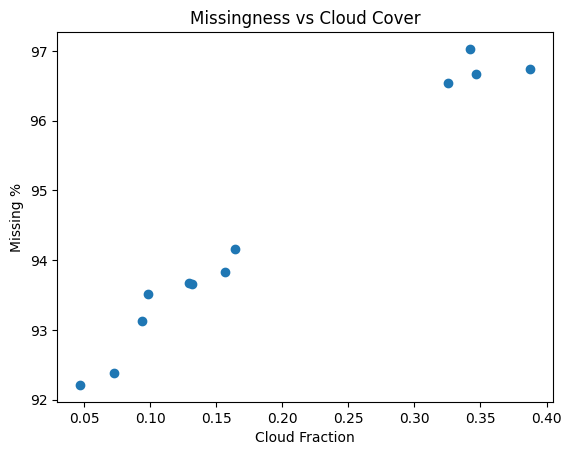

In [29]:

plt.figure()
plt.scatter(monthly_cloud, monthly_missing)
plt.xlabel("Cloud Fraction")
plt.ylabel("Missing %")
plt.title("Missingness vs Cloud Cover")
plt.show()


In [39]:
from IPython.display import Image

def show_monthly_missing_map(month_str):
    start = ee.Date(month_str)
    end = start.advance(1, 'month')
    
    monthly = collection.filterDate(start, end)
    
    def missing_fn(img):
        return img.select('tropospheric_NO2_column_number_density').mask().Not()
    
    missing = monthly.map(missing_fn).mean()
    no2 = monthly.select('tropospheric_NO2_column_number_density').mean()
    
    thumb_url = no2.visualize(
        min=0, max=0.0002,
        palette=['blue', 'green', 'yellow', 'red']
    ).getThumbURL({
        'region': region,
        'dimensions': 512
    })
    
    display(Image(url=thumb_url))



In [32]:
show_monthly_missing_map('2024-07-01')  # monsoon month
show_monthly_missing_map('2024-01-01')  # winter

In [33]:
def count_images(m):
    start = start_month.advance(m, 'month')
    end = start.advance(1, 'month')
    
    count = collection.filterDate(start, end).size()
    
    return ee.Image().set({
        'date': start.format('YYYY-MM'),
        'count': count
    })

counts = ee.ImageCollection(months.map(count_images))
monthly_counts = counts.aggregate_array('count').getInfo()

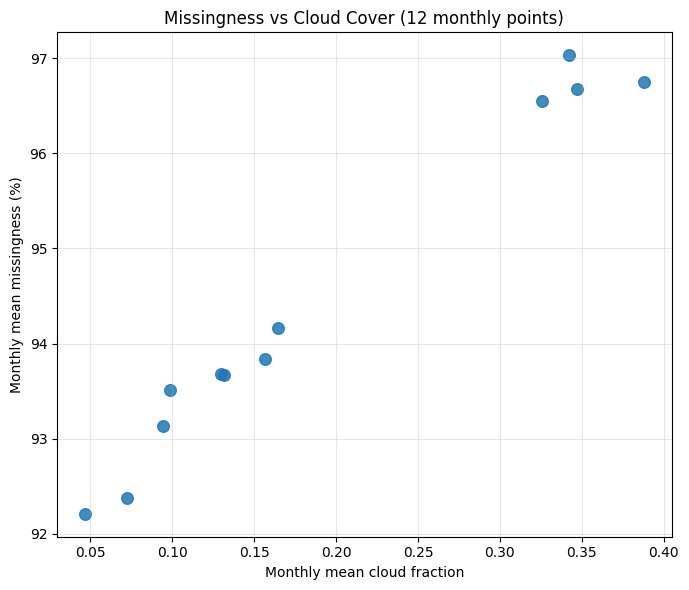

In [34]:
x = monthly_cloud
y = monthly_missing

if len(x) != len(y):
    raise ValueError(f"Length mismatch: monthly_cloud={len(x)}, monthly_missing={len(y)}")

plt.figure(figsize=(7, 6))
plt.scatter(x, y, s=70, alpha=0.85)

plt.xlabel("Monthly mean cloud fraction")
plt.ylabel("Monthly mean missingness (%)")
plt.title(f"Missingness vs Cloud Cover ({len(x)} monthly points)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Total observations: 5164
Estimated missing observations: 4878.1
Overall missing data: 94.46%


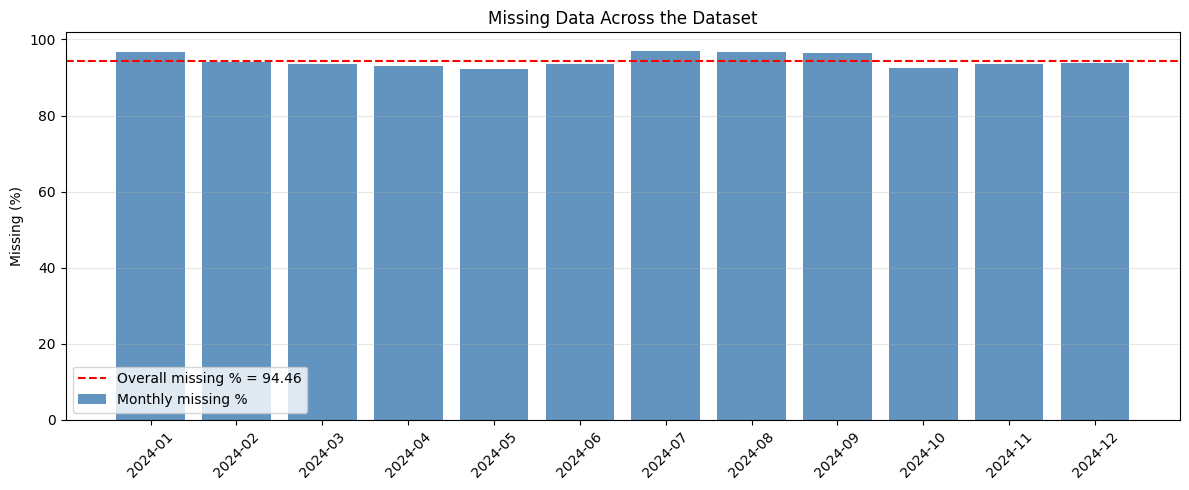

In [35]:
# Overall missingness across the dataset (weighted by monthly image count)
weights = np.array(monthly_num_images, dtype=float)
missing = np.array(monthly_missing, dtype=float)

overall_missing_pct = np.average(missing, weights=weights)
estimated_missing_obs = np.sum((missing / 100.0) * weights)
total_obs = np.sum(weights)

print(f"Total observations: {int(total_obs)}")
print(f"Estimated missing observations: {estimated_missing_obs:.1f}")
print(f"Overall missing data: {overall_missing_pct:.2f}%")

# Plot monthly missingness with overall average
plt.figure(figsize=(12, 5))
plt.bar(monthly_dates, monthly_missing, color='steelblue', alpha=0.85, label='Monthly missing %')
plt.axhline(overall_missing_pct, color='red', linestyle='--',
            label=f'Overall missing % = {overall_missing_pct:.2f}')

plt.xticks(rotation=45)
plt.ylabel("Missing (%)")
plt.title("Missing Data Across the Dataset")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Average missing data in 2024: 94.46%


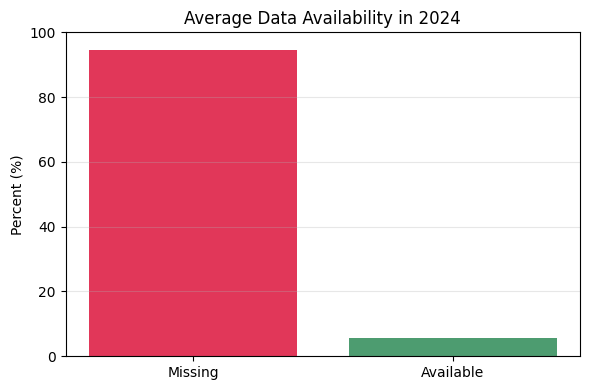

In [36]:
# Yearly average missing data (%)
if len(monthly_num_images) == len(monthly_missing):
    yearly_avg_missing = np.average(monthly_missing, weights=monthly_num_images)  # weighted
else:
    yearly_avg_missing = np.mean(monthly_missing)  # fallback

yearly_avg_available = 100 - yearly_avg_missing

print(f"Average missing data in {test_start[:4]}: {yearly_avg_missing:.2f}%")

plt.figure(figsize=(6, 4))
plt.bar(["Missing", "Available"], [yearly_avg_missing, yearly_avg_available],
        color=["crimson", "seagreen"], alpha=0.85)
plt.ylim(0, 100)
plt.ylabel("Percent (%)")
plt.title(f"Average Data Availability in {test_start[:4]}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout() 
plt.show()

Non-full images analyzed: 421
Average non-full images/day: 1.18
Images with missingness <= 10%: 40.9%
Images with missingness <= 20%: 46.1%


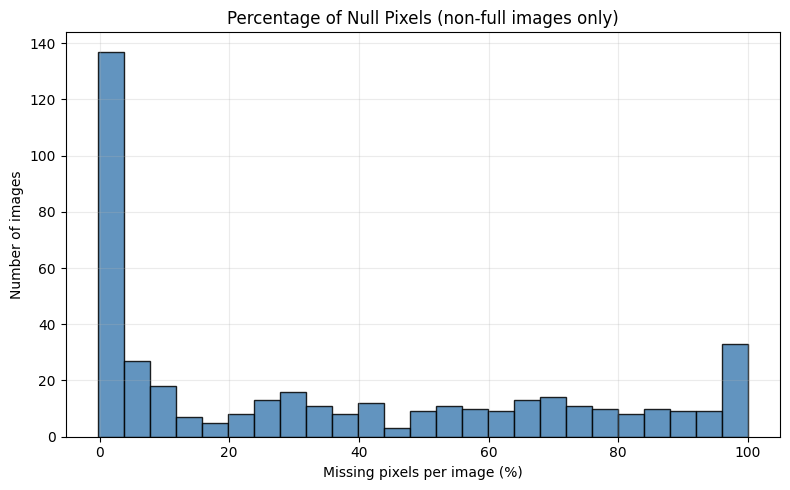

In [37]:
# Missingness distribution for images that are not fully null/zero in the study region

band = 'tropospheric_NO2_column_number_density'

year_collection = (
    collection
    .filterDate(test_start, test_end)
    .filterBounds(region)
    .select(band)
)

def annotate_image(img):
    # Regional mean NO2 (used to remove fully zero/null-like images)
    mean_dict = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    )
    mean_no2 = ee.Number(ee.Algorithms.If(mean_dict.contains(band), mean_dict.get(band), 0))

    # Valid (unmasked) pixel count
    valid_dict = img.mask().reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    )
    valid_count = ee.Number(ee.Algorithms.If(valid_dict.contains(band), valid_dict.get(band), 0))

    missing_pct_img = ee.Number(1).subtract(valid_count.divide(pixel_count)).multiply(100)

    return img.set({
        'date': img.date().format('YYYY-MM-dd'),
        'mean_no2': mean_no2,
        'valid_count': valid_count,
        'missing_pct_img': missing_pct_img
    })

annotated = year_collection.map(annotate_image)
non_full = annotated.filter(ee.Filter.gt('mean_no2', 0))

img_missing = np.array(non_full.aggregate_array('missing_pct_img').getInfo(), dtype=float)
img_dates = pd.to_datetime(non_full.aggregate_array('date').getInfo())

if img_missing.size == 0:
    print("No non-full images found for the selected period/region.")
else:
    daily_non_full = pd.Series(1, index=img_dates).groupby(img_dates.date).sum()
    avg_non_full_per_day = daily_non_full.mean()
    p10 = (img_missing <= 10).mean() * 100
    p20 = (img_missing <= 20).mean() * 100

    print(f"Non-full images analyzed: {img_missing.size}")
    print(f"Average non-full images/day: {avg_non_full_per_day:.2f}")
    print(f"Images with missingness <= 10%: {p10:.1f}%")
    print(f"Images with missingness <= 20%: {p20:.1f}%")

    plt.figure(figsize=(8, 5))
    plt.hist(img_missing, bins=25, color='steelblue', edgecolor='black', alpha=0.85)
    plt.xlabel("Missing pixels per image (%)")
    plt.ylabel("Number of images")
    plt.title("Percentage of Null Pixels (non-full images only)")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

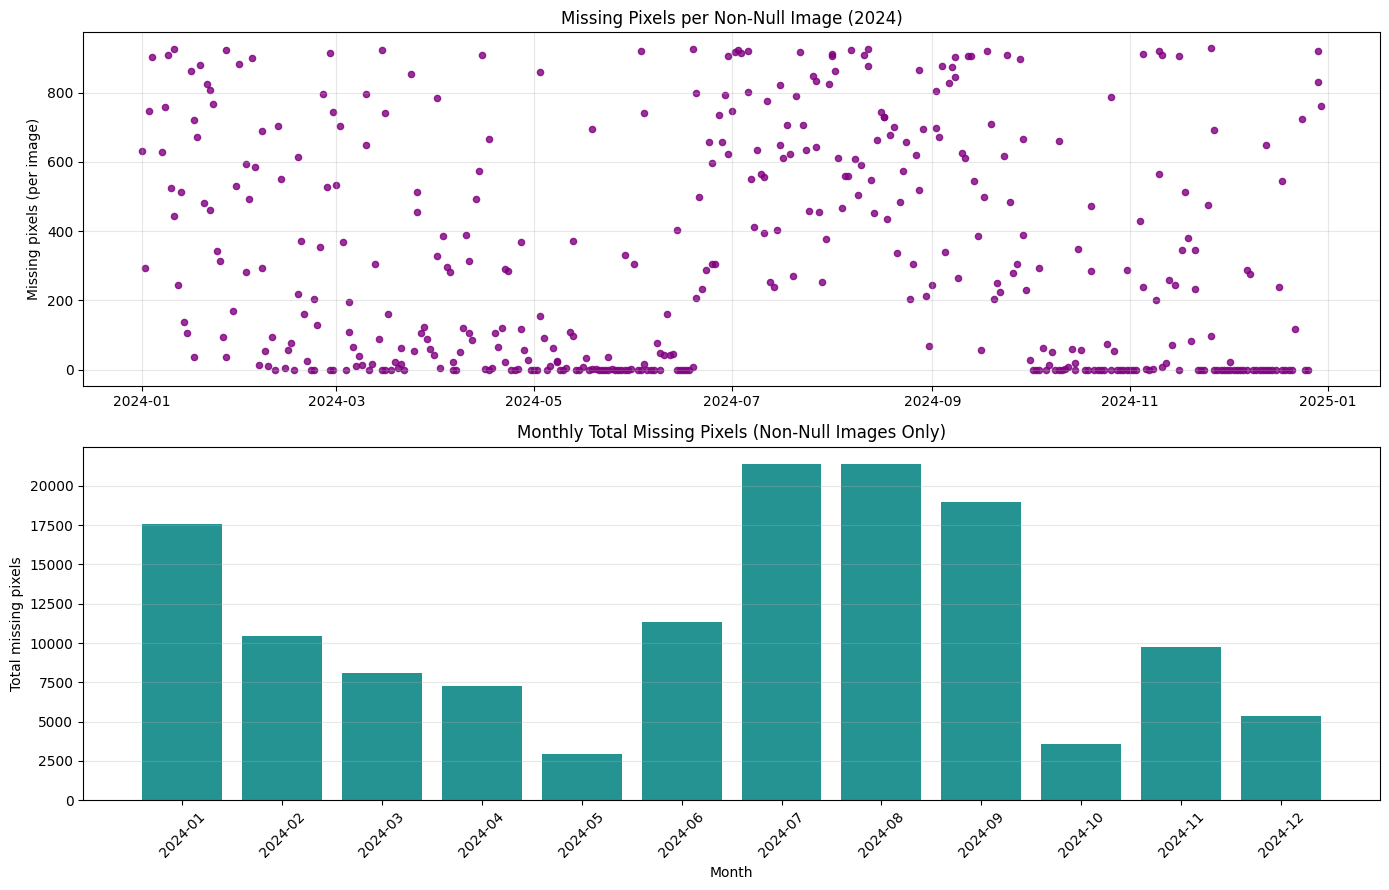

In [38]:
# Missing pixel counts per non-null image, and yearly variation

dates_nonnull = pd.to_datetime(non_full.aggregate_array("date").getInfo())
missing_pct_nonnull = np.array(non_full.aggregate_array("missing_pct_img").getInfo(), dtype=float)

if missing_pct_nonnull.size == 0:
    print("No non-null images found for the selected period/region.")
else:
    nonnull_df = pd.DataFrame({
        "date": dates_nonnull,
        "missing_pct": np.clip(missing_pct_nonnull, 0, 100)  # guard against tiny negative numeric noise
    }).sort_values("date")

    # Convert missing % to missing pixel count per image
    nonnull_df["missing_pixels"] = (nonnull_df["missing_pct"] / 100.0) * pixel_count
    nonnull_df["month"] = nonnull_df["date"].dt.to_period("M").astype(str)

    # Monthly totals across non-null images
    monthly_missing_pixels_nonnull = (
        nonnull_df.groupby("month", as_index=False)
        .agg(
            total_missing_pixels=("missing_pixels", "sum"),
            image_count=("missing_pixels", "size")
        )
    )

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

    # (1) Per-image missing pixels across the year
    axes[0].scatter(nonnull_df["date"], nonnull_df["missing_pixels"], s=20, alpha=0.8, color="purple")
    axes[0].set_title("Missing Pixels per Non-Null Image (2024)")
    axes[0].set_ylabel("Missing pixels (per image)")
    axes[0].grid(alpha=0.3)

    # (2) Monthly total missing pixels (non-null images only)
    axes[1].bar(
        monthly_missing_pixels_nonnull["month"],
        monthly_missing_pixels_nonnull["total_missing_pixels"],
        color="teal",
        alpha=0.85
    )
    axes[1].set_title("Monthly Total Missing Pixels (Non-Null Images Only)")
    axes[1].set_ylabel("Total missing pixels")
    axes[1].set_xlabel("Month")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    monthly_missing_pixels_nonnull
